# **Assignment-Exploratory Data Analysis of Titanic Data Set**
---




#**1. Introduction to the Dataset**

The Titanic training dataset contains information about the passengers of the Titanic ship— like their age, gender, ticket class, and whether they survived. Here we will be analyzing the survival rate of passengers based on the features provided in the dataset.

#**2. Importing Necessary Libraries**

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#**3. Loading the DataSet**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Python_Programme/Titanic_train.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#**4. Initial Data Exploration**




In [4]:
df.head() # First 5 rows of dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape # (number of rows; passengers, number of columns; features)

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Gender count of Passengers
Gender_counts = df['Sex'].value_counts()

print(Gender_counts)


Sex
male      577
female    314
Name: count, dtype: int64


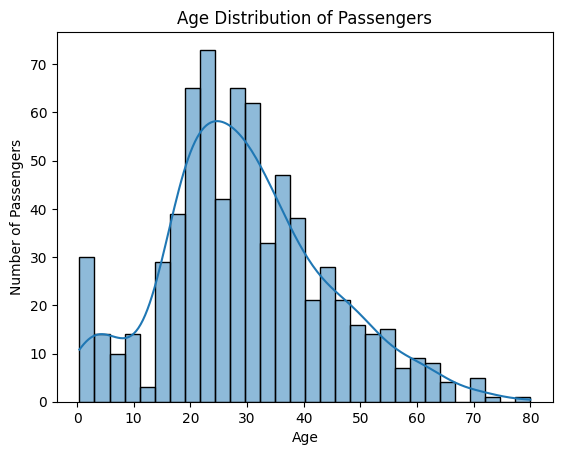

In [8]:
# Age Distribution of Passengers
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

In [9]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


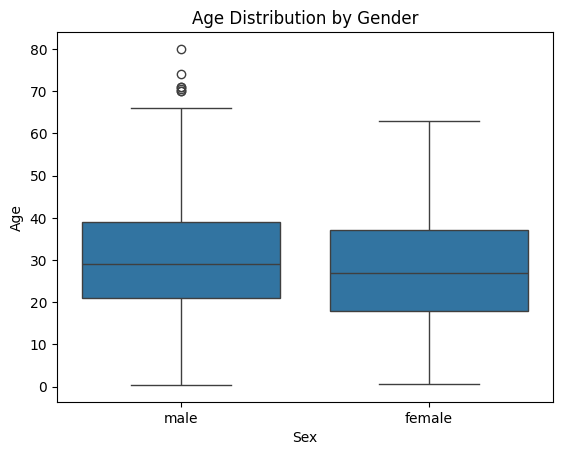

In [10]:
# Gender-wise Age distribution
sns.boxplot(x='Sex', y='Age', data=df)
plt.title('Age Distribution by Gender')
plt.show()

Half of the passengers were young in the working age group age of 20-40 years.

In [11]:
# Port of Embarkment
embark_counts = df['Embarked'].value_counts()

print(embark_counts)


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Number of passengers boarded from S = Southampton is highest at 644, followed by C = Cherbourg (168) and Q = Queenstown (77).

In [12]:
# Pclass gives us a basic information about socio-economic status
print(df['Pclass'].unique())

[3 1 2]


In [13]:
pclass_counts = df['Pclass'].value_counts()
print(pclass_counts)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [14]:
pclass_embark_counts = pd.crosstab(df['Pclass'], df['Embarked'])

print(pclass_embark_counts)

Embarked   C   Q    S
Pclass               
1         85   2  127
2         17   3  164
3         66  72  353


#**5. Data Cleaning and Pre-processing**

In [15]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [16]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing_df)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


In [17]:
missing_age_by_sex = df[df['Age'].isnull()].groupby('Sex').size()

print(missing_age_by_sex)

Sex
female     53
male      124
dtype: int64


We have missing values for Age 177 or 19.87%, Cabin - 687 or 77% and Embarked columns - 2 or 0.22 %. Age records of 124 males and 53 females are missing.

In [18]:
# 5A: Handle Missing Values

# Age → Fill with Median as the fillna stays more representative. Median is chosen because Age distribution contains outliers.
df['Age'] = df['Age'].fillna(df['Age'].median())

# Cabin: this column is dropped entirely because 77% of values are missing.
df_new = df.drop('Cabin', axis=1, inplace=True, errors='ignore')

# Embarked: Fill with the most common port, we use the MODE (most frequently occurring value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [19]:
df_new=df.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

#**6. Feature Engineering**

In [20]:
# FamilySize = SibSp (siblings + spouse) + Parch (parents + children) + 1 (yourself)
# Raw family variables separately may hide patterns. FamilySize combines total social group.
# A person traveling alone might behave differently from someone in a big family. Families might have stayed together and blocked escape routes, or families with children may have been given priority.

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [21]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,28.0,1,2,23.4500,S,4
889,1,1,male,26.0,0,0,30.0000,C,1


#**7. Exploratory Data Analysis**

In [22]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


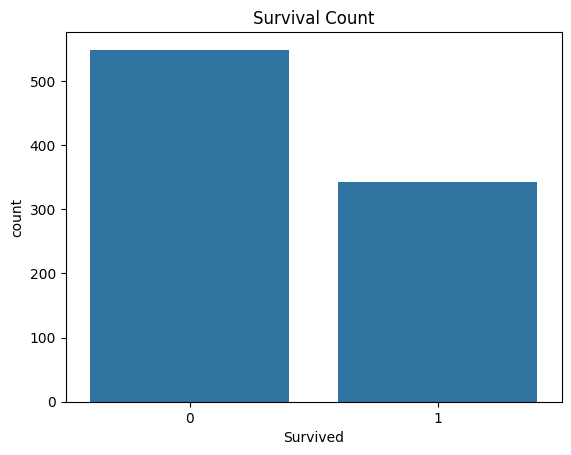

In [23]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

In [24]:
# Survival vs Gender
df_survivors_by_Gender = df[df['Survived'] == 1]['Sex'].value_counts()

In [25]:
df_survivors_by_Gender

,count
Sex,
female,233
male,109


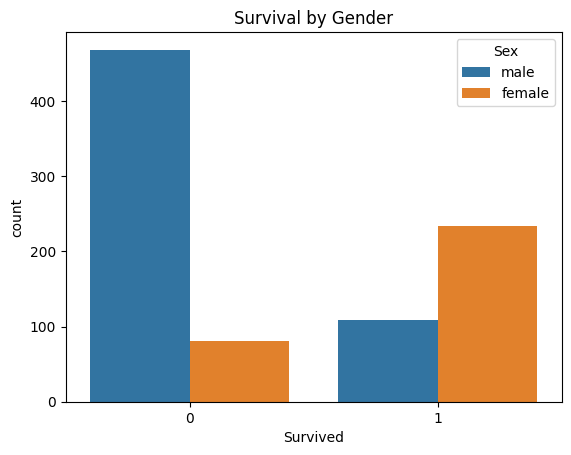

In [26]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()

Evidently, focus was more to rescue women as the above graph shows us women survivors were far more compared to men.

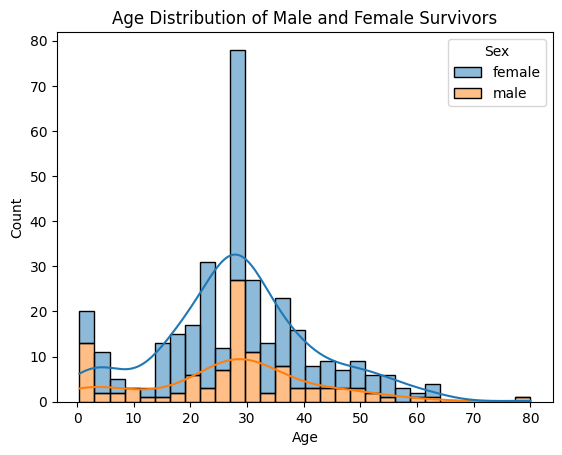

In [27]:
# Filter survivors
survivors = df[df['Survived'] == 1]

# Plot age distributions for male and female survivors
sns.histplot(data=survivors, x='Age', hue='Sex', bins=30, kde=True, edgecolor='black', multiple='stack')
plt.title('Age Distribution of Male and Female Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [28]:
# Create age groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,12,18,30,45,60,80],
    labels=['Child (0-12)','Teen (13-18)','Young Adult (19-30)','Adult (31-45)','Middle Age (46-60)','Senior (61-80)']
)

print(df['Age_Group'])

0      Young Adult (19-30)
1            Adult (31-45)
2      Young Adult (19-30)
3            Adult (31-45)
4            Adult (31-45)
              ...         
886    Young Adult (19-30)
887    Young Adult (19-30)
888    Young Adult (19-30)
889    Young Adult (19-30)
890          Adult (31-45)
Name: Age_Group, Length: 891, dtype: category
Categories (6, object): ['Child (0-12)' < 'Teen (13-18)' < 'Young Adult (19-30)' < 'Adult (31-45)' <
                         'Middle Age (46-60)' < 'Senior (61-80)']


In [29]:
# Calculate Survival Percentage
survival_pct = df.groupby(['Age_Group','Sex'])['Survived'].mean() * 100

/tmp/ipykernel_695/3097283154.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_pct = df.groupby(['Age_Group','Sex'])['Survived'].mean() * 100


In [30]:
# Convert to Table Format for Plotting
survival_pct = survival_pct.unstack()

print(survival_pct)

Sex                      female       male
Age_Group                                 
Child (0-12)          59.375000  56.756757
Teen (13-18)          75.000000   8.823529
Young Adult (19-30)   72.727273  14.473684
Adult (31-45)         78.082192  22.480620
Middle Age (46-60)    85.185185  18.518519
Senior (61-80)       100.000000  10.526316


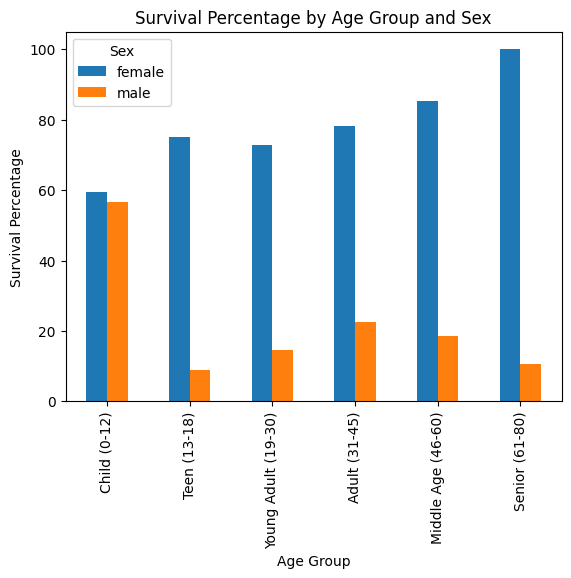

In [31]:
survival_pct.plot(kind='bar')

plt.title("Survival Percentage by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.legend(title="Sex")
plt.show()

Female survival rate is much higher than male survival rate across among all age groups.

Children have relatively higher survival rates compared to adult men.

Adult males often show the lowest survival percentages.

This reflects the “Women and Children First” evacuation policy followed during the Titanic disaster.

/tmp/ipykernel_695/3982173433.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_survival, x='FamilySize', y='Survived',
/tmp/ipykernel_695/3982173433.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_survival, x='IsAlone', y='Survived',
/tmp/ipykernel_695/3982173433.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['With Family', 'Alone'])


[Text(0, 0, 'With Family'), Text(1, 0, 'Alone')]

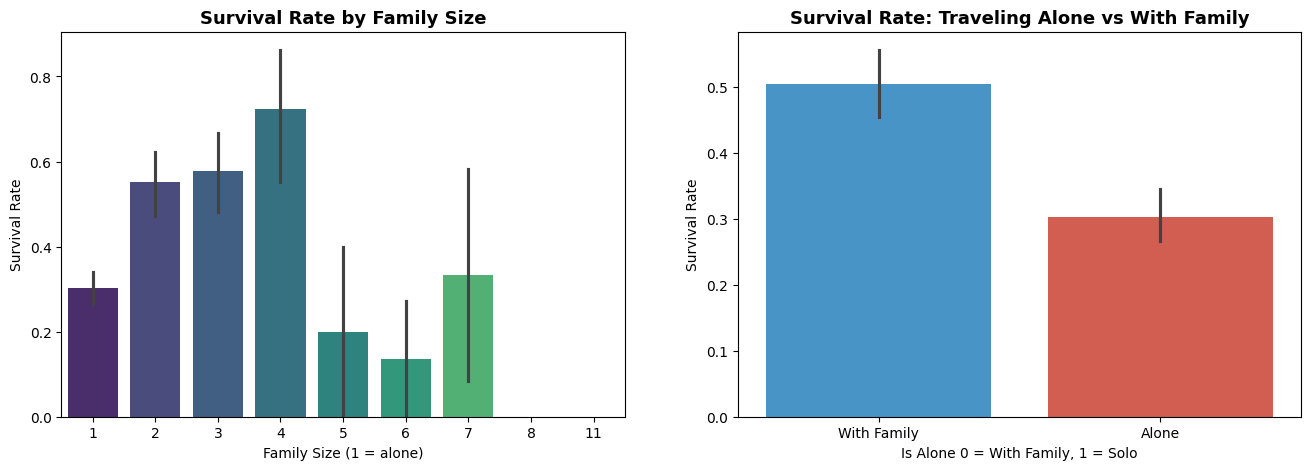

In [32]:
# Visualize new features

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Family size vs survival
family_survival = df.copy()
family_survival['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.barplot(data=family_survival, x='FamilySize', y='Survived',
            palette='viridis', ax=axes[0])
axes[0].set_title('Survival Rate by Family Size', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Family Size (1 = alone)')
axes[0].set_ylabel('Survival Rate')

# Is alone vs survival
family_survival['IsAlone'] = (family_survival['FamilySize'] == 1).astype(int)
sns.barplot(data=family_survival, x='IsAlone', y='Survived',
            palette={'0': '#3498db', '1': '#e74c3c'}, ax=axes[1]) # Changed integer keys to string keys
axes[1].set_title('Survival Rate: Traveling Alone vs With Family', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Is Alone 0 = With Family, 1 = Solo')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['With Family', 'Alone'])

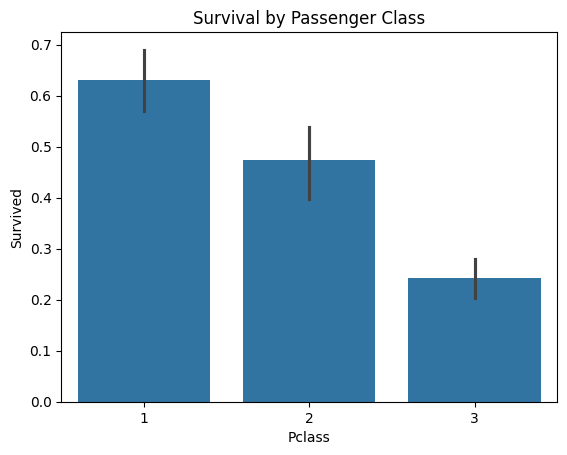

In [33]:
# Probability of Survival vs Passenger Class
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()


First-class passengers had higher survival rates.

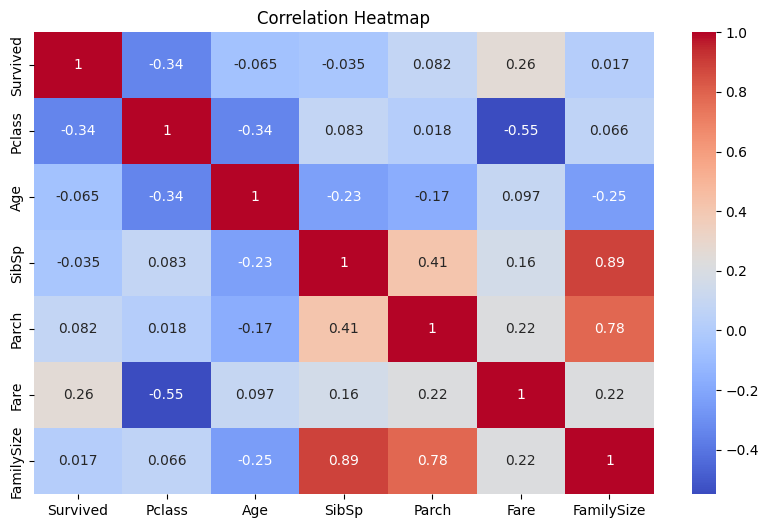

In [34]:
# Correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

1. Positive correlation:
   a. **Fare (+0.26)**: This means that passengers who paid higher fares had a higher chance of survival. This is intuitive, as higher fares often corresponded to better cabins, potentially on upper decks, and thus easier access to lifeboats.


   b. **Parch (+0.082)**: This indicates a positive, albeit weak, correlation between the number of parents/children aboard and survival. This could suggest that individuals with immediate family members (children or parents) on board might have been prioritized during evacuation or had a stronger motivation to survive and reach safety with their loved ones.


   c. **FamilySize (+0.017)**: Having a small to medium-sized family (not traveling alone, but not in a very large group) showed a slight positive correlation with survival, suggesting some benefits of mutual support during the evacuation.


2. Negative correlation:
   a. **Pclass (-0.34)**: This is the strongest negative correlation. It indicates that as the `Pclass` value increases (meaning going from 1st class to 2nd class to 3rd class), the survival rate decreases. In other words, passengers in 1st class had a significantly higher chance of survival compared to those in 3rd class.
  
  
   b. **Age (-0.065)**: A slight negative correlation suggests that, in general, older passengers had a marginally lower survival rate than younger ones, though this is less pronounced than other factors.
   
   
   c. **SibSp (-0.035)**: A very weak negative correlation, indicating that having more siblings or spouses aboard might slightly decrease survival chances, possibly due to larger family groups being harder to evacuate.



#**8. Key Findings from the Titanic Analysis**
1. Gender Was the Strongest Factor:
74.2% of women survived vs only 18.9% of men.
The Titanic followed a "women and children first" evacuation policy
This was the single biggest predictor of survival.
2. Passenger Class Mattered Enormously:
1st Class: ~62.9% survival rate
2nd Class: ~47.3% survival rate
3rd Class: ~24.2% survival rate
Wealthier passengers had cabins closer to the deck, and may have had better access to lifeboats.
3. Children Had Better Survival Rates:
Young children (especially under 10) were prioritized in evacuation
Adults aged 20-35 (mostly working-class men) had the highest death rates.
4. Family Size Made a Difference:
Passengers with small families (2-4 members) survived better than solo travelers.
Very large families had lower survival — harder to coordinate evacuation.